# Exp7.4 — Latent Softmax Evidence Ablation

Aggregate-only analysis notebook. It reads the finalized Exp7.4 artifacts and does **not** train models or submit jobs.

Primary question: how much performance changes when the Exp7.3 A2 direct linear head is replaced by a factorized head, a latent softmax bottleneck, and a softmax bottleneck with deterministic RMS magnitude restoration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd()
if not (repo / 'notebooks').exists():
    repo = repo.parent
base = repo / 'notebooks' / 'artifacts' / 'experiment_7_4_latent_softmax_evidence' / 'latent_softmax_evidence_v1'
manifest = json.loads((base / 'manifest.json').read_text())
runs = pd.read_csv(base / 'method_runs.csv')
summary = pd.read_csv(base / 'method_summary.csv')
contrast_runs = pd.read_csv(base / 'contrast_runs.csv')
contrasts = pd.read_csv(base / 'contrast_summary.csv')
manifest


{'architecture': '234x234',
 'checkpoint_rule': 'native validation BA primary, native WCCE loss tiebreak',
 'counts': {'methods': 4, 'parallel_runs': 12, 'seeds': 3},
 'experiment_id': 'experiment_7_4_latent_softmax_evidence',
 'hypotheses': {'B_minus_A': 'Controls for adding a factorized 128x128 then 128x12 linear head.',
  'C_minus_B': 'Isolates the effect of per-timestep 128-way softmax normalization.',
  'D_minus_C': 'Tests whether restoring deterministic latent RMS magnitude recovers performance lost by softmax normalization.'},
 'methods': ['A_a2_direct_linear',
  'B_two_linear',
  'C_latent_softmax',
  'D_latent_softmax_rms'],
 'objective': 'wcce',
 'pairing_contract': 'All methods reuse Exp7.3 A2 model-init and loader seeds. Case A is intended as a strict A2 replication.',
 'primary_metric': 'native_test_balanced_accuracy',
 'protocol_version': 'latent_softmax_evidence_v1',
 'regularization': 'task_only',
 'seeds': [11, 23, 37],
 'shifts': [[2, 3, 4], [2, 3, 4]],
 'temperature'

## 1. Main result — test balanced accuracy

In [2]:
main_cols = [
    'method', 'head', 'head_trainable_parameters',
    'test_ba_mean', 'test_ba_std',
    'l2_wholecount_probe_test_ba_mean',
    'l2_fixed250_probe_test_ba_mean',
    'best_epoch_mean',
]
main = summary[main_cols].copy()
for col in ['test_ba_mean', 'test_ba_std', 'l2_wholecount_probe_test_ba_mean', 'l2_fixed250_probe_test_ba_mean']:
    main[col] = 100 * main[col]
main.rename(columns={
    'test_ba_mean': 'test_BA_%',
    'test_ba_std': 'test_BA_std_pp',
    'l2_wholecount_probe_test_ba_mean': 'L2_wholecount_probe_BA_%',
    'l2_fixed250_probe_test_ba_mean': 'L2_fixed250_probe_BA_%',
}, inplace=True)
main.round(2)

,method,head,head_trainable_parameters,test_BA_%,test_BA_std_pp,L2_wholecount_probe_BA_%,L2_fixed250_probe_BA_%,best_epoch_mean
0,A_a2_direct_linear,direct,1536,56.45,3.28,58.63,58.73,91.00
1,B_two_linear,two_linear,17920,51.11,1.26,52.55,55.65,63.67
2,C_latent_softmax,softmax,17920,25.74,6.45,47.80,51.34,69.67
3,D_latent_softmax_rms,softmax_rms,17920,39.26,9.02,46.71,50.61,79.67


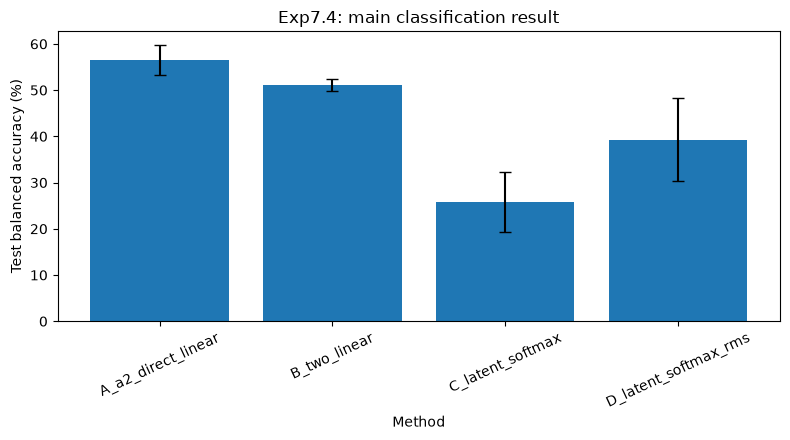

In [3]:
plot_df = summary[['method', 'test_ba_mean', 'test_ba_std']].copy()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(plot_df['method'], 100 * plot_df['test_ba_mean'], yerr=100 * plot_df['test_ba_std'], capsize=4)
ax.set_ylabel('Test balanced accuracy (%)')
ax.set_xlabel('Method')
ax.set_title('Exp7.4: main classification result')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
plt.show()

## 2. Paired mechanistic contrasts

These are the comparisons the experiment was designed to isolate:

- **B − A**: cost of replacing the direct 128→12 head with two linear matrices.
- **C − B**: effect of inserting the per-timestep 128-way softmax normalization.
- **D − C**: recovery after restoring deterministic latent RMS magnitude.
- **D − B**: residual gap between softmax+RMS and the matched two-linear control.

In [4]:
contrast_view = contrasts[[
    'contrast', 'left_method', 'right_method',
    'test_ba_delta_pp_mean', 'test_ba_delta_pp_std',
    'l2_wholecount_probe_delta_pp_mean', 'l2_wholecount_probe_delta_pp_std',
]].copy()
contrast_view.round(2)

,contrast,left_method,right_method,test_ba_delta_pp_mean,test_ba_delta_pp_std,l2_wholecount_probe_delta_pp_mean,l2_wholecount_probe_delta_pp_std
0,B_minus_A_factorization,B_two_linear,A_a2_direct_linear,-5.34,2.21,-6.08,4.72
1,C_minus_B_softmax_normalization,C_latent_softmax,B_two_linear,-25.37,7.59,-4.75,3.26
2,D_minus_C_restore_rms_magnitude,D_latent_softmax_rms,C_latent_softmax,13.52,2.68,-1.09,5.85
3,D_minus_B_softmax_plus_magnitude_vs_linear,D_latent_softmax_rms,B_two_linear,-11.85,10.20,-5.84,8.35


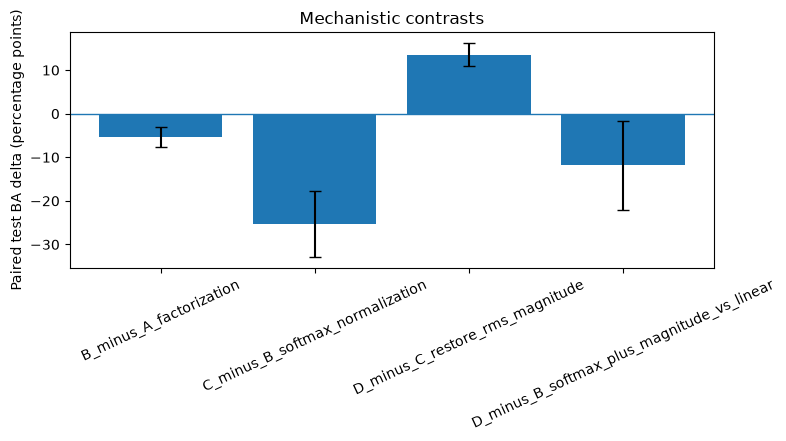

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(contrasts['contrast'], contrasts['test_ba_delta_pp_mean'], yerr=contrasts['test_ba_delta_pp_std'], capsize=4)
ax.axhline(0, linewidth=1)
ax.set_ylabel('Paired test BA delta (percentage points)')
ax.set_title('Mechanistic contrasts')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
plt.show()

## 3. L2 representation quality

The two probe columns test whether end-to-end training changes how linearly accessible the class information remains at L2. This helps separate a head-only effect from representation damage.

In [6]:
probe_cols = [
    'method',
    'l2_wholecount_probe_test_ba_mean', 'l2_wholecount_probe_test_ba_std',
    'l2_fixed250_probe_test_ba_mean', 'l2_fixed250_probe_test_ba_std',
]
probe = summary[probe_cols].copy()
for col in probe.columns:
    if col != 'method':
        probe[col] = 100 * probe[col]
probe.round(2)

,method,l2_wholecount_probe_test_ba_mean,l2_wholecount_probe_test_ba_std,l2_fixed250_probe_test_ba_mean,l2_fixed250_probe_test_ba_std
0,A_a2_direct_linear,58.63,0.97,58.73,1.71
1,B_two_linear,52.55,4.13,55.65,0.78
2,C_latent_softmax,47.80,4.15,51.34,0.88
3,D_latent_softmax_rms,46.71,5.50,50.61,4.20


## 4. Softmax and magnitude diagnostics

In [7]:
diag_cols = [
    'method',
    'test_latent_rms_mean_mean',
    'test_softmax_entropy_mean_mean',
    'test_softmax_entropy_normalized_mean_mean',
    'test_softmax_max_prob_mean_mean',
    'test_softmax_effective_states_mean_mean',
    'test_magnitude_rms_mean_mean',
    'test_evidence_rms_mean_mean',
]
summary[diag_cols].round(3)

,method,test_latent_rms_mean_mean,test_softmax_entropy_mean_mean,test_softmax_entropy_normalized_mean_mean,test_softmax_max_prob_mean_mean,test_softmax_effective_states_mean_mean,test_magnitude_rms_mean_mean,test_evidence_rms_mean_mean
0,A_a2_direct_linear,NaN,NaN,NaN,NaN,NaN,NaN,3.772
1,B_two_linear,0.994,NaN,NaN,NaN,NaN,NaN,7.705
2,C_latent_softmax,5.343,1.041,0.214,0.752,21.465,NaN,0.321
3,D_latent_softmax_rms,30.113,1.531,0.315,0.561,22.692,30.113,6.530


## 5. Current interpretation from the completed runs

Using the finalized three-seed aggregate currently in the artifact directory:

- **A — direct A2 head:** 56.45% test BA.
- **B — two linear matrices:** 51.11% test BA, a **−5.34 pp** drop vs A. So the factorized 128→128→12 parameterization is already not neutral in end-to-end training, even though it is algebraically linear.
- **C — latent softmax:** 25.74% test BA, another **−25.37 pp** vs B. This is the dominant degradation and strongly supports the hypothesis that per-timestep softmax normalization removes information the classifier was using.
- **D — softmax + RMS magnitude:** 39.26% test BA, recovering **+13.52 pp** vs C. Therefore magnitude is clearly important, but RMS magnitude alone does not recover the full information lost by the softmax bottleneck; D remains **−11.85 pp** below B.

The L2 probes also deteriorate from A to B/C/D, so part of the loss is not merely at the final head: the end-to-end objective changes the learned L2 representation itself.

The main mechanistic conclusion is therefore:

$$\boxed{\text{softmax loses substantially more than just a scalar evidence magnitude}}$$

Restoring one scalar magnitude recovers a large fraction of the loss, but not all of it. The remaining gap is consistent with information loss from simplex normalization itself (for example common-mode / logit-offset information and detailed signed relative amplitudes), plus end-to-end representation adaptation.

## 6. Per-seed sanity check

In [8]:
runs[['method', 'seed', 'test_ba', 'l2_wholecount_probe_test_ba', 'l2_fixed250_probe_test_ba', 'best_epoch']].sort_values(['method', 'seed']).round(4)

,method,seed,test_ba,l2_wholecount_probe_test_ba,l2_fixed250_probe_test_ba,best_epoch
0,A_a2_direct_linear,11,0.5306,0.5758,0.5716,94
4,A_a2_direct_linear,23,0.5962,0.5879,0.6055,89
8,A_a2_direct_linear,37,0.5667,0.5951,0.5846,90
1,B_two_linear,11,0.5021,0.5342,0.5485,56
5,B_two_linear,23,0.5256,0.5617,0.5642,65
9,B_two_linear,37,0.5057,0.4805,0.5569,70
2,C_latent_softmax,11,0.3254,0.5182,0.5175,92
6,C_latent_softmax,23,0.1971,0.4804,0.5193,37
10,C_latent_softmax,37,0.2497,0.4353,0.5033,80
3,D_latent_softmax_rms,11,0.4830,0.5155,0.5204,84
